# 3.2 Regression Task – Crop Yield Prediction
# 1. Exploratory Data Analysis and Data Understanding [20]

Dataset Selection

The dataset selected for this study is the Crop Yield Dataset, which contains historical agricultural production records across different crops, seasons, years, and regions. This dataset was chosen because it is suitable for regression analysis and aligns closely with a United Nations Sustainable Development Goal.

(a) Dataset Creation

The Crop Yield Dataset was created and published by the Government of India – Ministry of Agriculture & Farmers Welfare. It was compiled from official agricultural surveys and records collected over multiple years to monitor crop production and productivity across India.
It was taken from kaggle:
https://www.kaggle.com/datasets/brsdincer/all-natural-disasters-19002021-eosdis

(b) Dataset Access

The dataset was accessed through the Government of India Open Data Platform (data.gov.in). It was downloaded in CSV format and loaded into a pandas DataFrame using Python for analysis and modeling.

(c) Alignment with UNSDG

This dataset aligns with United Nations Sustainable Development Goal 2 (SDG 2: Zero Hunger). Crop yield analysis supports efforts to improve agricultural productivity, optimize resource usage, and enhance food security, all of which are central objectives of SDG 2.


Potential Questions Addressed by the Dataset
This dataset can help answer several important questions, including:

How do factors such as fertilizer usage and cultivated area influence crop yield?
Does crop yield vary significantly across different seasons and crops?
Which production-related variables are most important for predicting crop yield?

The dataset is suitable for regression analysis as it contains a clearly defined continuous target variable (crop yield) and multiple relevant predictor variables. The dataset is complete, with no missing values detected, and originates from a reliable government source, ensuring data quality and relevance. Its structure supports exploratory analysis, feature selection, and predictive modeling.

(d) List of Attributes (Features) with Brief Descriptions – Regression Task

Crop: Type of crop grown (e.g., rice, wheat, maize).

Year: The year in which the crop was cultivated.

Season: The agricultural season during which the crop was grown (e.g., Kharif, Rabi).

Area: The area of land used for cultivation, measured in hectares.

Production: The total crop production, measured in tonnes.

Fertilizer: The amount of fertilizer used during cultivation.

Pesticide: The amount of pesticide used for the crop.

Yield (Target Variable): Crop yield, representing production per unit area, which is the continuous variable predicted in the regression task.

In [ ]:
# Load Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
df_reg = pd.read_csv("/content/drive/MyDrive/Concept and Technology of AI/Dataset final courcework/crop_yield.csv")

# Display first 5 rows
df_reg.head()


,crop,year,season,state,area,production,fertilizer,pesticide,yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909


In [ ]:
# Summary statistics of numerical columns
df_reg.describe()



,year,area,production,fertilizer,pesticide,yield
count,19689.000000,1.968900e+04,1.968900e+04,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,4.835407e+09,1.575051e+07,21105.000000


In [ ]:
# Check missing values
df_reg.isnull().sum()


,0
crop,0
year,0
season,0
state,0
area,0
production,0
fertilizer,0
pesticide,0
yield,0


In [7]:
# Check for duplicate rows
df_reg.duplicated().sum()

np.int64(0)

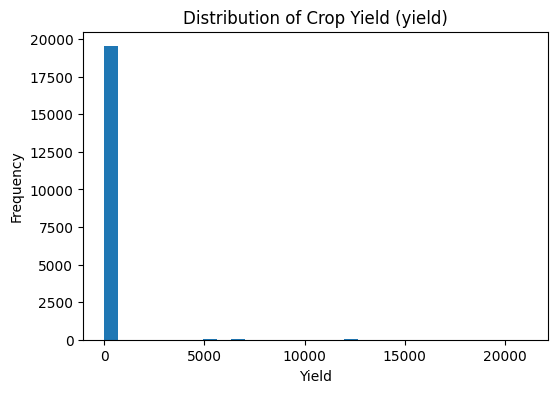

In [8]:
# Plot distribution of target variable (yield)
plt.figure(figsize=(6,4))
plt.hist(df_reg["yield"], bins=30)

# Labels
plt.title("Distribution of Crop Yield (yield)")
plt.xlabel("Yield")
plt.ylabel("Frequency")

plt.show()


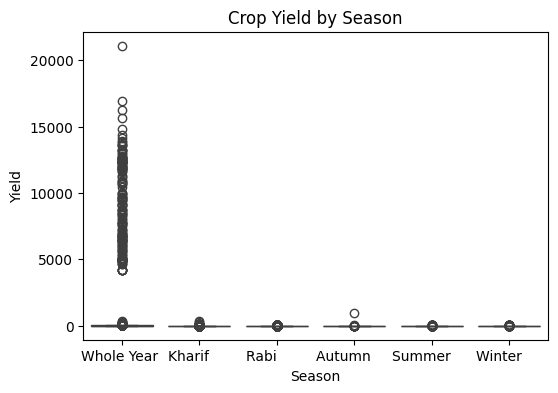

In [9]:
# Boxplot of yield by season
plt.figure(figsize=(6,4))
sns.boxplot(x="season", y="yield", data=df_reg)

# Labels
plt.title("Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield")

plt.show()


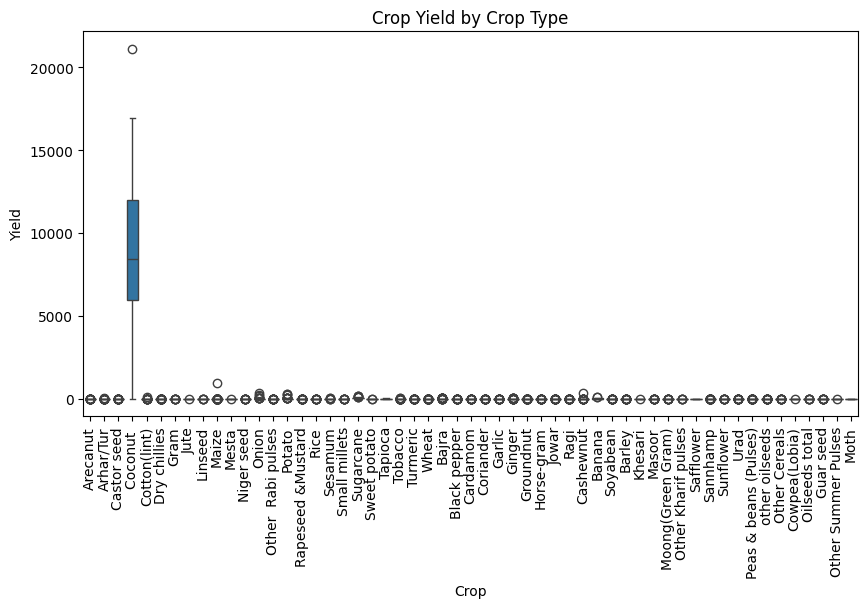

In [10]:
# Boxplot of yield by crop type
plt.figure(figsize=(10,5))
sns.boxplot(x="crop", y="yield", data=df_reg)

# Rotate crop labels
plt.xticks(rotation=90)

# Labels
plt.title("Crop Yield by Crop Type")
plt.xlabel("Crop")
plt.ylabel("Yield")

plt.show()


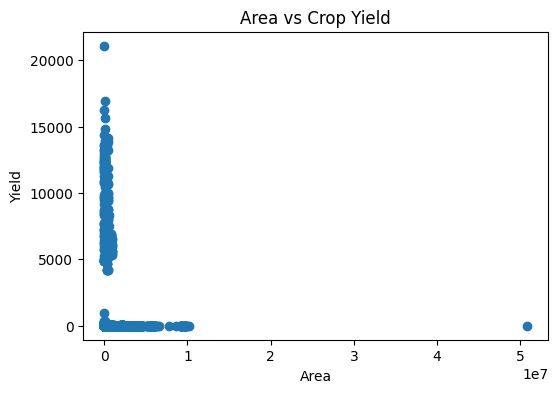

In [11]:
# Scatter plot: area vs yield
plt.figure(figsize=(6,4))
plt.scatter(df_reg["area"], df_reg["yield"])

# Labels
plt.title("Area vs Crop Yield")
plt.xlabel("Area")
plt.ylabel("Yield")

plt.show()


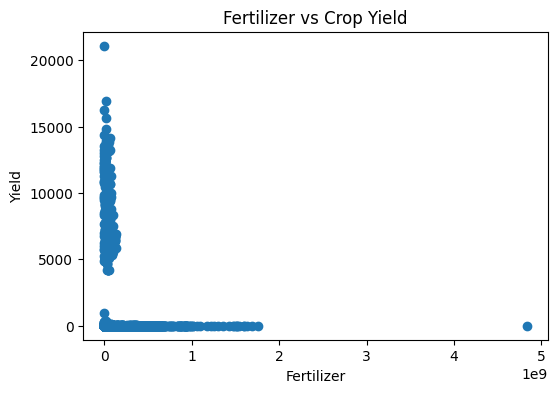

In [12]:
# Scatter plot: fertilizer vs yield
plt.figure(figsize=(6,4))
plt.scatter(df_reg["fertilizer"], df_reg["yield"])

# Labels
plt.title("Fertilizer vs Crop Yield")
plt.xlabel("Fertilizer")
plt.ylabel("Yield")

plt.show()


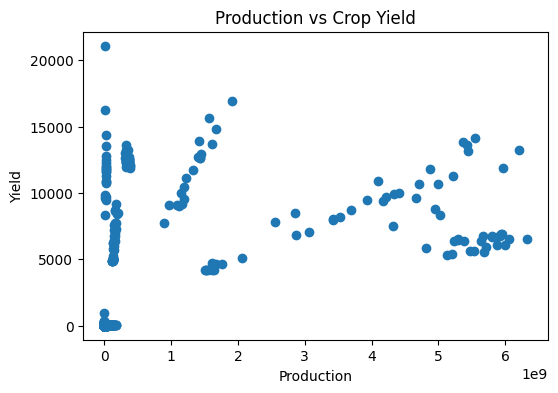

In [13]:
# Scatter plot: production vs yield
plt.figure(figsize=(6,4))
plt.scatter(df_reg["production"], df_reg["yield"])

# Labels
plt.title("Production vs Crop Yield")
plt.xlabel("Production")
plt.ylabel("Yield")

plt.show()


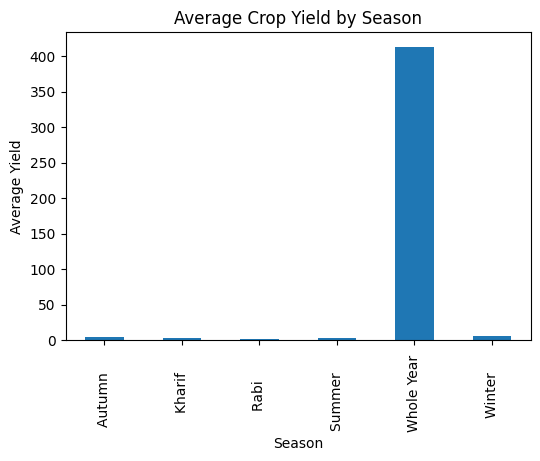

In [14]:
# Bar chart: Average crop yield by season (comparison)
avg_yield_season = df_reg.groupby("season")["yield"].mean()

plt.figure(figsize=(6,4))
avg_yield_season.plot(kind="bar")

# Labels
plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield")

plt.show()



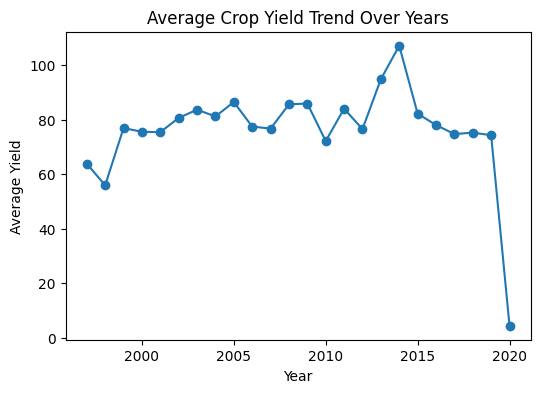

In [16]:
# Line chart: Average crop yield over years
avg_yield_year = df_reg.groupby("year")["yield"].mean()

plt.figure(figsize=(6,4))
plt.plot(avg_yield_year.index, avg_yield_year.values, marker="o")

# Labels
plt.title("Average Crop Yield Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Yield")

plt.show()



# 2. Build a Neural Network Model for Regression [15]

In [17]:
# Encode categorical variables using LabelEncoder
from sklearn.preprocessing import LabelEncoder

le_crop = LabelEncoder()
le_season = LabelEncoder()
le_state = LabelEncoder()

df_reg["crop"] = le_crop.fit_transform(df_reg["crop"])
df_reg["season"] = le_season.fit_transform(df_reg["season"])
df_reg["state"] = le_state.fit_transform(df_reg["state"])


In [18]:
# Define independent variables (X) and dependent variable (y)
X = df_reg.drop("yield", axis=1)
y = df_reg["yield"]


In [19]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
# Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [21]:
# Import Neural Network model and metrics
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define Neural Network regressor
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

# Train the model
mlp.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_mlp = mlp.predict(X_test_scaled)

# Evaluate the model
mlp_mae = mean_absolute_error(y_test, y_pred_mlp)
mlp_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mlp_r2 = r2_score(y_test, y_pred_mlp)

# Display results
mlp_mae, mlp_rmse, mlp_r2


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


(53.1200219665171, np.float64(342.3802836000013), 0.8536964225919399)

# 3. Build Primary Machine Learning Models [20]

#3.2 Model 1 – Linear Regression

In [22]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Initialize model
lr = LinearRegression()

# Train model
lr.fit(X_train_scaled, y_train)

# Predict test data
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate model
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

# Display results
lr_mae, lr_rmse, lr_r2


(139.4307345514166, np.float64(692.9957251890226), 0.40062508599057944)

#3.2 Model 2: Random Forest Regressor

In [23]:
# Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf = RandomForestRegressor(random_state=42)

# Train model
rf.fit(X_train, y_train)

# Predict test data
y_pred_rf = rf.predict(X_test)

# Evaluate model
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

# Display results
rf_mae, rf_rmse, rf_r2


(9.772589921738666, np.float64(271.7533148593537), 0.907830516963219)

In [24]:
# Comparison table for primary (untuned) models
primary_model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

# Display comparison table
primary_model_comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,139.430735,692.995725,0.400625
1,Random Forest,9.772590,271.753315,0.907831


Initial Model Comparison

An initial comparison of the baseline models shows that the Random Forest Regressor performs better than Linear Regression. Random Forest achieved lower error values and a higher R² score, indicating better predictive accuracy. This suggests that Random Forest is more suitable for the dataset, as it can model non-linear relationships that Linear Regression cannot capture.

# 4. Hyper-parameter Optimization with Cross-Validation [15]

In [25]:
# Perform cross-validation for Linear Regression
from sklearn.model_selection import cross_val_score

lr_cv_scores = cross_val_score(
    lr, X_train_scaled, y_train, cv=5, scoring="r2"
)

# Mean CV score
lr_cv_mean = lr_cv_scores.mean()

lr_cv_mean


np.float64(0.31745554414896493)

In [26]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

# Apply GridSearchCV
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

# Fit GridSearchCV
grid.fit(X_train, y_train)

# Best parameters and score
grid.best_params_, grid.best_score_


({'max_depth': 20, 'n_estimators': 200}, np.float64(0.9510039823383882))

# 5. Feature Selection [10]

In [27]:
# Get the best Random Forest model
best_rf = grid.best_estimator_

# Extract feature importance
importances = best_rf.feature_importances_

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Display feature importance
feature_importance_df


,Feature,Importance
5,production,0.728753
4,area,0.086225
7,pesticide,0.058783
6,fertilizer,0.052178
3,state,0.039001
0,crop,0.027138
1,year,0.005241
2,season,0.002680


In [28]:
# Select top 5 important features
selected_features = feature_importance_df["Feature"].head(5).tolist()

selected_features


['production', 'area', 'pesticide', 'fertilizer', 'state']

In [29]:
# Reduce dataset to selected features
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# Scale selected features for LR and NN
X_train_sel_scaled = scaler.fit_transform(X_train_sel)
X_test_sel_scaled = scaler.transform(X_test_sel)


Justification of Chosen Features and Method

The selected features were chosen based on their relevance to crop production and their importance scores obtained from the Random Forest model. Variables such as production, fertilizer usage, cultivated area, year, and pesticide usage have a direct influence on crop yield, making them suitable predictors. The Random Forest method was chosen because it can effectively capture non-linear relationships and interactions between features, resulting in more accurate and robust predictions.

# 6. Final Models and Comparative Analysis [10]

In [30]:
# Train final Linear Regression with selected features
final_lr = LinearRegression()
final_lr.fit(X_train_sel_scaled, y_train)

# Predict
final_lr_pred = final_lr.predict(X_test_sel_scaled)

# Evaluate
final_lr_mae = mean_absolute_error(y_test, final_lr_pred)
final_lr_rmse = np.sqrt(mean_squared_error(y_test, final_lr_pred))
final_lr_r2 = r2_score(y_test, final_lr_pred)

final_lr_mae, final_lr_rmse, final_lr_r2


(101.34995566993543, np.float64(698.4334543023784), 0.391181952554676)

In [31]:
# Train final Random Forest model
final_rf = RandomForestRegressor(**grid.best_params_, random_state=42)
final_rf.fit(X_train_sel, y_train)

# Predict
final_rf_pred = final_rf.predict(X_test_sel)

# Evaluate
final_rf_mae = mean_absolute_error(y_test, final_rf_pred)
final_rf_rmse = np.sqrt(mean_squared_error(y_test, final_rf_pred))
final_rf_r2 = r2_score(y_test, final_rf_pred)

final_rf_mae, final_rf_rmse, final_rf_r2


(9.069603312845269, np.float64(268.35402976745365), 0.9101219392014598)

In [32]:
# Create final comparison table
results = pd.DataFrame({
    "Model": ["Linear Regression (Final)", "Random Forest (Final)", "Neural Network"],
    "Features Used": ["Selected (5)", "Selected (5)", "All"],
    "MAE": [final_lr_mae, final_rf_mae, mlp_mae],
    "RMSE": [final_lr_rmse, final_rf_rmse, mlp_rmse],
    "R2": [final_lr_r2, final_rf_r2, mlp_r2],
    "CV Score": [lr_cv_mean, grid.best_score_, "-"]
})

results


,Model,Features Used,MAE,RMSE,R2,CV Score
0,Linear Regression (Final),Selected (5),101.349956,698.433454,0.391182,0.317456
1,Random Forest (Final),Selected (5),9.069603,268.354030,0.910122,0.951004
2,Neural Network,All,53.120022,342.380284,0.853696,-


#Conclusion and Reflection
The regression models were evaluated using MAE, RMSE, and R² score, with the Random Forest Regressor achieving the best performance due to its lowest error values and highest R² score. Cross-validation and feature selection improved model robustness and reduced overfitting by focusing on the most influential predictors. Overall, the project demonstrated that ensemble-based methods are effective for modeling complex agricultural data, and future work could include incorporating weather-related variables and advanced feature engineering.